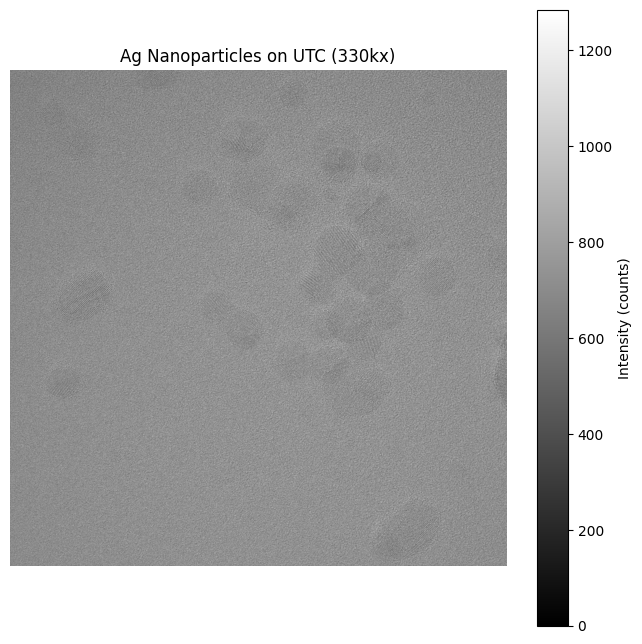

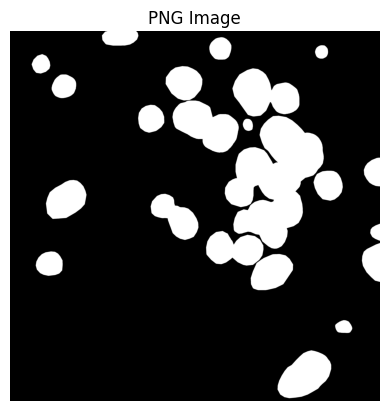

In [1]:
from ncempy.io import dm
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

file = Path("../hrtem_files/2022_02_02 5nm Ag nanoparticles on UTC/20220202_Ag_UTC_330kx_2650e_0p1596s_02.dm3")
label_file = Path("../hrtem_files/2022_02_02 5nm Ag nanoparticles on UTC/Labels/20220202_Ag_UTC_330kx_2650e_0p1596s_02_label.png")

# Load the DM3 file
data_dict = dm.dmReader(str(file.resolve()))

image_data = data_dict['data']
plt.figure(figsize=(8, 8))
plt.imshow(image_data, cmap='gray')
plt.title("Ag Nanoparticles on UTC (330kx)")
plt.colorbar(label='Intensity (counts)')
plt.axis('off') 
plt.show()


img = mpimg.imread(label_file)

plt.imshow(img, cmap='gray')
plt.axis('off')
plt.title("PNG Image")
plt.show()

In [2]:
from skimage.util import view_as_blocks

def split_patches(patch_size, image):
    blocks = view_as_blocks(image, block_shape=(patch_size, patch_size))
    patches = blocks.reshape(-1, patch_size, patch_size)

    return patches

In [6]:
patched_image = split_patches(32, image_data)

In [8]:
from scipy import ndimage
from persim import plot_diagrams
from ripser import lower_star_img
from persim import PersistenceImager
import numpy as np

pimgr = PersistenceImager(
    pixel_size = 16,
    birth_range=(400, 700),
    pers_range=(0, 300)
)

def PH_patch(patched_image):
    dgms = []
    for p in patched_image:      
        dgm = lower_star_img(p)
        dgm = dgm[np.isfinite(dgm[:,1])]
        dgms.append(dgm)
    pimgr.fit(dgms)
    vectors = []
    for dgm in dgms:
        pimg = pimgr.transform(dgm)
        vec = pimg.ravel()
        vectors.append(vec)
    vectors = np.vstack(vectors)
    return dgms, vectors

dgms, vectorised_patches = PH_patch(patched_image)

/home/eng-6770/Documents/TEM_Exploration/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/eng-6770/Documents/TEM_Exploration/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/tmp/ipykernel_170290/3331302418.py:17: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(


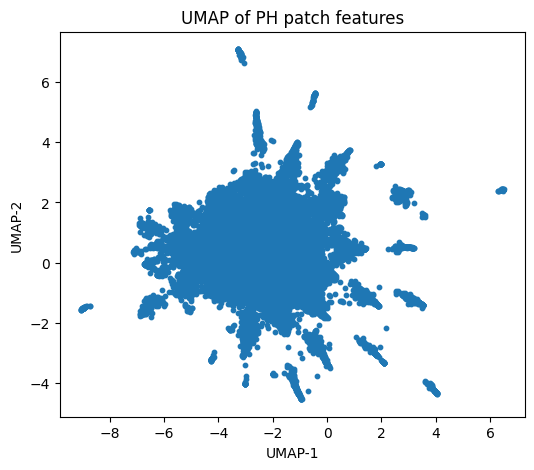

In [9]:
from sklearn.preprocessing import StandardScaler
import umap

X = StandardScaler().fit_transform(vectorised_patches)

reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric="euclidean",
    random_state=42
)

embedding = reducer.fit_transform(X)

plt.figure(figsize=(6,5))
plt.scatter(
    embedding[:,0],
    embedding[:,1],
    s=10,
    cmap="Spectral"
)
plt.title("UMAP of PH patch features")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.show()

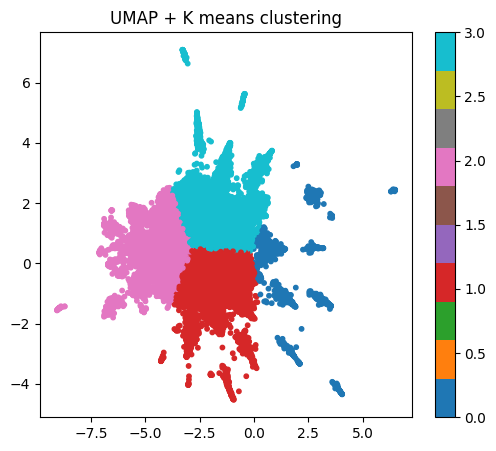

In [10]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
labels = kmeans.fit_predict(embedding)

plt.figure(figsize=(6,5))
plt.scatter(
    embedding[:,0],
    embedding[:,1],
    c=labels,
    cmap="tab10",
    s=10
)
plt.title("UMAP + K means clustering")
plt.colorbar()
plt.show()

In [13]:
def get_positions(image_data):

    blocks = view_as_blocks(image_data, block_shape=(32, 32))
    n_rows, n_cols = blocks.shape[:2]

    positions = [
        (i * 32, j * 32)
        for i in range(n_rows)
        for j in range(n_cols)
    ]

    return positions

import numpy as np

def label_to_image(original_image, labels, positions):

    H, W = original_image.shape[:2]
    label_img = np.zeros((H, W), dtype=int)

    for (r, c), lab in zip(positions, labels):
        label_img[r:r+32, c:c+32] = lab

    return label_img

In [14]:
positions = get_positions(image_data)
label_img = label_to_image(image_data, labels, positions)

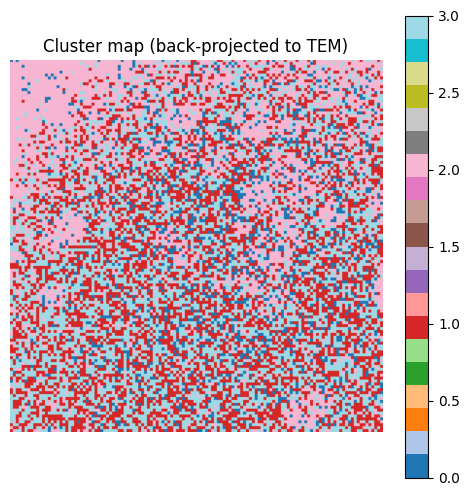

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.imshow(label_img, cmap="tab20")
plt.title("Cluster map (back-projected to TEM)")
plt.colorbar()
plt.axis("off")
plt.show()

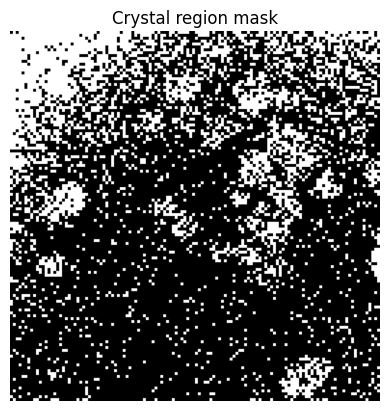

In [16]:
target_cluster = 2 

mask = (label_img == target_cluster).astype(np.uint8)

plt.imshow(mask, cmap="gray")
plt.title("Crystal region mask")
plt.axis("off")
plt.show()

/home/eng-6770/Documents/TEM_Exploration/.venv/lib/python3.14/site-packages/skimage/_shared/utils.py:386: UserWarning: Only one label was provided to `remove_small_objects`. Did you mean to use a boolean array?
  return func(*args, **kwargs)
/tmp/ipykernel_170290/1445258119.py:7: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  clean = binary_closing(clean_mask, footprint=disk(2))


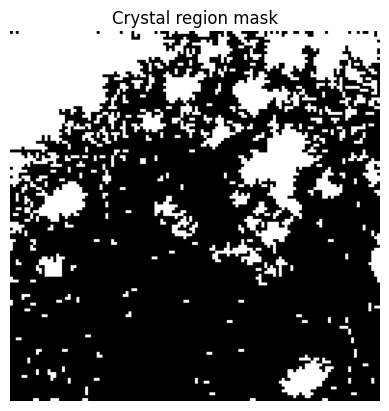

In [17]:
from skimage.morphology import remove_small_objects
from scipy.ndimage import binary_fill_holes
from skimage.morphology import binary_closing, disk

clean_mask = remove_small_objects(mask, max_size=100)
clean_mask = binary_fill_holes(clean_mask)
clean = binary_closing(clean_mask, footprint=disk(2))
clean_mask = remove_small_objects(clean_mask, max_size=1600)
plt.imshow(clean_mask, cmap="gray")
plt.title("Crystal region mask")
plt.axis("off")
plt.show()